# DMQ Hyperparameter Tuning with Optuna

This notebook is designed to experimentally tune the DMQ model using Optuna. The process is as follows:

1.  **Data Preparation**: Load the data and split it into a training set (up to Dec 1997) and a test set (Jan 1998 - Dec 2024).
2.  **Evaluation Metrics**: Define R-squared for mean forecasts and quantile loss for quantile forecasts.
3.  **Optuna Study**: Define an objective function for Optuna to search for the best hyperparameters.
4.  **Analysis**: Analyze the results of the best trial and visualize the forecasts.

## 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import optuna
from operator import itemgetter
import keras

from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

from src.data.prepare_data import prepare_quantile_data
from src.train.models import build_dmq_v0
from src.train.losses import quantile_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score, estimate_mean_from_quantiles
from src.train.tuning import CVObjective

import yaml
import os

keras.utils.set_random_seed(1)

with open("./config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

## 2. Data Preparation

In [15]:
target_path = './data/processed/us_4q_fred_y.csv'
input_paths = ['./data/processed/us_4q_fred_x.csv', 
               './data/processed/us_4q_oap_vw_x_stationary.csv']

# Prepare data (including RNN sequences)
non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=0,
    time_steps=12,
    targets_path=target_path,
    input_paths=input_paths,
    start_date='1961-01-01',
    train_cutoff_year='1997',
    n_quantiles=5,
    val_years=5
)

# Extract RNN data for training and testing
y_train_rnn = rnn_data['mq_y_train_rnn']
y_val_rnn = rnn_data['mq_y_val_rnn']
y_train_full_rnn = rnn_data['mq_y_train_full_rnn']
y_test_rnn = rnn_data['mq_y_test_rnn']
all_y_test_full = non_rnn_data['all_y_test_full']  # Assuming this is the full test set of true values for evaluation
X_train_rnn = rnn_data['X_train_rnn']
X_val_rnn = rnn_data['X_val_rnn']
X_train_full_rnn = rnn_data['X_train_full_rnn']
X_test_rnn = rnn_data['X_test_rnn']
X_test_rnn_full = rnn_data['X_test_rnn_full']

print(f"Training data shape: {X_train_rnn.shape}")
print(f"Validation data shape: {X_val_rnn.shape}")
print(f"Test data shape: {X_test_rnn.shape}")

Train: 1961-01-01 to 1992-12-01 00:00:00
Validation: 1993-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00
Training data shape: (373, 12, 270)
Validation data shape: (60, 12, 270)
Test data shape: (12, 12, 270)


## 3. Run Optuna Study

In [ ]:
# Define fit parameters
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, y_val_rnn),
    'verbose': 0,
    'shuffle': False
}

early_stopping_args = {
    'monitor': 'val_loss',
    'patience': 5,
    'min_delta': 1e-3,
    'restore_best_weights': True
}

# load dmq_grid from config file
dmq_grid = config['tuning']['dmq_grid']


# Instantiate the objective class
objective = CVObjective(
    X_tr=X_train_full_rnn,
    y_tr=y_train_full_rnn,
    val_size=0.2, # use 20% of the training data for validation during cross-validation
    n_splits=5, # Using 5 splits for cross-validation
    fit_params=fit_params,
    early_stopping_args=early_stopping_args,
    builder_func=build_dmq_v0,
    n_jobs=1,
    grid=dmq_grid,
    # Pass fixed arguments for the builder function
    input_shape=X_train_rnn.shape[1:],
    lower_quantiles=[q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q < 0.5],
    upper_quantiles=[q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q > 0.5],
    rec_drop=0.0,
    dropout=0.0,
    norm_fn='layer'
    recurrent_layer_type='slstm_block',
    loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28],
    n_recurrent_layers=1,
    n_shared_layers=1,
    n_qtask_layers=1,
    n_recurrent_nodes=64,
    n_shared_nodes=64,
    n_task_nodes=64,
    recurrent_norm=True
    shared_norm=True,
    task_norm=True
)

study = optuna.create_study(
    direction='minimize', 
    sampler=optuna.samplers.RandomSampler(seed=1),
    pruner=optuna.pruners.MedianPruner(),
    storage='sqlite:///dmq_slstm_block_tuning.db', 
    load_if_exists=True
)
study.optimize(objective, n_trials=50, n_jobs=os.cpu_count()-1) # Run for 50 trials
 
print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-06-04 14:17:52,036] A new study created in RDB with name: no-name-82b40ae0-fb4b-41cd-b9b0-d30689da983f


In [5]:
# Save trial history as a csv for inspection
trial_history = pd.DataFrame(study.trials_dataframe())
trial_history.to_csv('dmq_xlstm_tuning_history.csv', index=False)

## 4. Analyze and Visualize Best Model

In [30]:
pd.date_range(meta_data['train_start'], meta_data['test_end'], freq='MS')

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01',
               ...
               '1998-03-01', '1998-04-01', '1998-05-01', '1998-06-01',
               '1998-07-01', '1998-08-01', '1998-09-01', '1998-10-01',
               '1998-11-01', '1998-12-01'],
              dtype='datetime64[ns]', length=456, freq='MS')

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 0.1898 - val_loss: 0.1439
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1516 - val_loss: 0.1390
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1404 - val_loss: 0.1350
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1348 - val_loss: 0.1321
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1319 - val_loss: 0.1291
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1301 - val_loss: 0.1260
Epoch 7/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1272 - val_loss: 0.1235
Epoch 8/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1247 - val_loss: 0.1220
Epoch 9/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1217 - val_loss: 0.1197
Epoch 10/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1188 - val_loss: 0.1160
Epoch 11/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1163 - val_loss: 0.1139
Epoch 12/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/ste

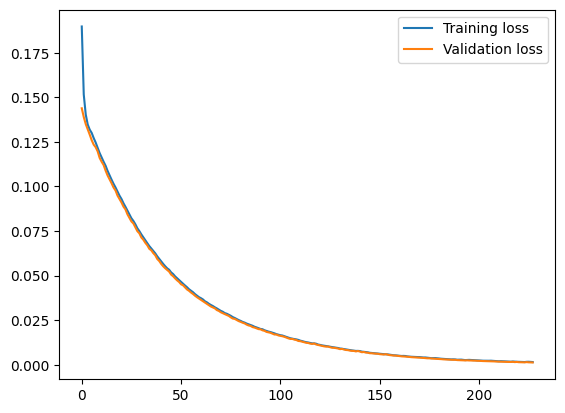

In [16]:
# Get best hyperparameters
# best_params = study.best_params
best_params = {
    'l2': 0.0001,
    'l1': 0.0,
    'lr': 1e-3
}
builder_params = {
    'input_shape': X_train_rnn.shape[1:],
    'lower_quantiles': [q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q < 0.5],
    'upper_quantiles': [q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q > 0.5],
    'recurrent_layer_type': 'lstm',
    'num_heads': 1,
    'loss_weights': [0.28, 0.17, 0.11, 0.17, 0.28],
    'norm_fn': 'layer',
    'n_recurrent_layers': 2,
    'n_shared_layers': 2,
    'n_qtask_layers': 2,
    'n_recurrent_nodes': 128,
    'n_shared_nodes': 64,
    'n_task_nodes': 32,
    'recurrent_norm': True,
    'shared_norm': True,
    'task_norm': True
}
builder_params.update(best_params)
# best_params ={
#     'n_recurrent_layers': 1,
#     'n_shared_layers': 1,
#     'n_qtask_layers': 1,
#     'n_recurrent_nodes': 32,
#     'n_shared_nodes': 32,
#     'n_task_nodes': 32,
#     'l2': 1e-4,
#     'l1': 0.0,
#     'lr': 1e-3
# }
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Build and train the best model on the full training data
best_model = build_dmq_v0(
    **builder_params
)

subset_size = 1.0
n = X_train_full_rnn.shape[0]

history = best_model.fit(
    X_train_full_rnn[:int(n*subset_size)], y_train_full_rnn[:int(n*subset_size)],
    epochs=300,
    batch_size=32,
    validation_data=(X_val_rnn, y_val_rnn),
    callbacks=[
        # keras.callbacks.ModelCheckpoint(
        #     'tuning_checkpoint.keras',
        #     monitor='val_loss',
        #     save_best_only=True
        # ),
        EarlyStopping(
            monitor='val_loss', 
            patience=5, 
            min_delta=1e-4, 
            restore_best_weights=True
            )
    ],
    verbose=1,
    shuffle=False
)

# Make predictions on the test set
train_preds = best_model.predict(X_train_full_rnn[:int(n*subset_size)])
test_preds = best_model.predict(X_test_rnn_full)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [61]:
X_train_rnn.shape

(373, 12, 123)

In [17]:
# --- Correctly Calculate Benchmarks and Scores ---

# Combine all true y values to create a continuous series for the expanding mean benchmark
full_y_series = pd.Series(
    np.concatenate([y_train_full_rnn[:, 0], all_y_test_full.iloc[:, 0]]),
    index=pd.date_range(meta_data['train_start'], '2024-12-01', freq='MS')[(11):]
)

# Calculate expanding mean over the whole series
expanding_mean_benchmark_full = full_y_series.expanding().mean()

# Align benchmark with train and test sets
train_benchmark_mean = expanding_mean_benchmark_full.loc[meta_data['train_start']:meta_data['val_end']].values
test_benchmark_mean = expanding_mean_benchmark_full.loc[meta_data['test_start']:'2024-12-01'].values

# Ensure benchmark has the same shape
train_benchmark_mean = train_benchmark_mean.flatten()
test_benchmark_mean = test_benchmark_mean.flatten()

# Estimate mean from quantile predictions
train_mean_preds = estimate_mean_from_quantiles(train_preds).flatten()
test_mean_preds = estimate_mean_from_quantiles(test_preds).flatten()

# Calculate R2 scores
train_r2 = compute_oos_r2_score(y_train_full_rnn[:, 0], train_mean_preds, train_benchmark_mean)
r2 = compute_oos_r2_score(all_y_test_full.iloc[:, 0], test_mean_preds, test_benchmark_mean)

# Calculate R1 scores for each quantile
train_r1_scores = []
for i, q in enumerate(quantiles):
    # For R1, the benchmark is also an expanding quantile
    expanding_q_benchmark = full_y_series.expanding().quantile(q)
    train_benchmark_q = expanding_q_benchmark.loc[meta_data['train_start']:meta_data['val_end']].values.flatten()
    train_r1_scores.append(compute_oos_r1_score(y_train_full_rnn[:, i], train_preds[:, i], train_benchmark_q, q))

r1_scores = []
for i, q in enumerate(quantiles):
    expanding_q_benchmark = full_y_series.expanding().quantile(q)
    test_benchmark_q = expanding_q_benchmark.loc[meta_data['test_start']:'2024-12-01'].values.flatten()
    r1_scores.append(compute_oos_r1_score(all_y_test_full.iloc[:, 0], test_preds[:, i], test_benchmark_q, q))


print(f"Best Model Train R-squared (for mean): {train_r2:.4f}")
print(f"Best Model Train Mean R1 Score: {np.mean(train_r1_scores):.4f}")
print(f"Best Model Test R-squared (for mean): {r2:.4f}")
print(f"Best Model Test Mean R1 Score: {np.mean(r1_scores):.4f}")

Best Model Train R-squared (for mean): 95.0945
Best Model Train Mean R1 Score: -97.8463
Best Model Test R-squared (for mean): 16.5525
Best Model Test Mean R1 Score: 67.8131


In [62]:
X_train_full_rnn.shape

(433, 12, 123)

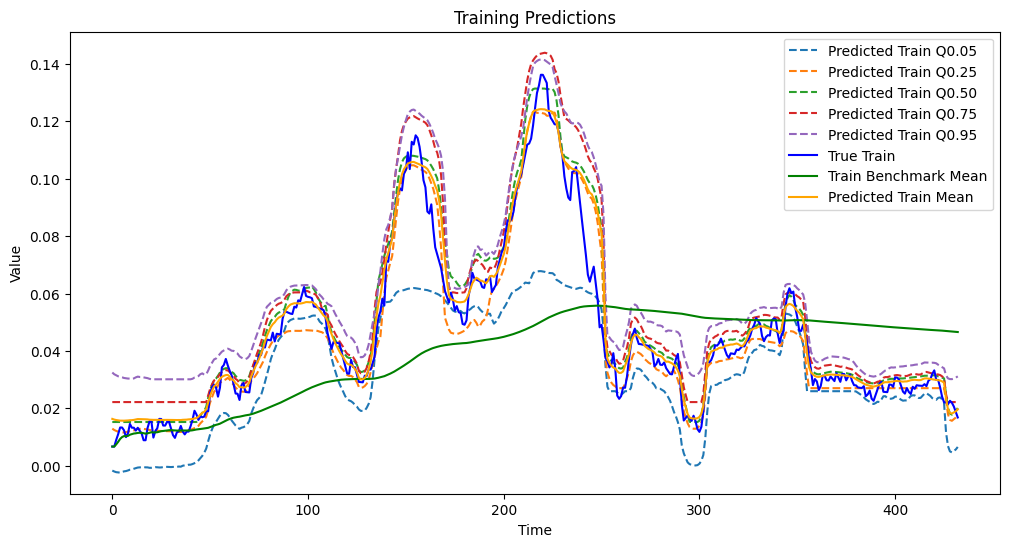

In [18]:
# plot the training predictions with the training quantiles
# train_mean_preds = np.array([0.15,0.225,0.25,0.225,0.15]) @ train_preds.transpose()
plt.figure(figsize=(12, 6))
for i, q in enumerate(quantiles):
    plt.plot(train_preds[:, i], label=f'Predicted Train Q{q:.2f}', linestyle='--')
plt.plot(y_train_full_rnn[:, 0], label='True Train', color='blue')
plt.plot(train_benchmark_mean, label='Train Benchmark Mean', color='green')
plt.plot(train_mean_preds, label='Predicted Train Mean', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Training Predictions')
plt.legend()
plt.show()

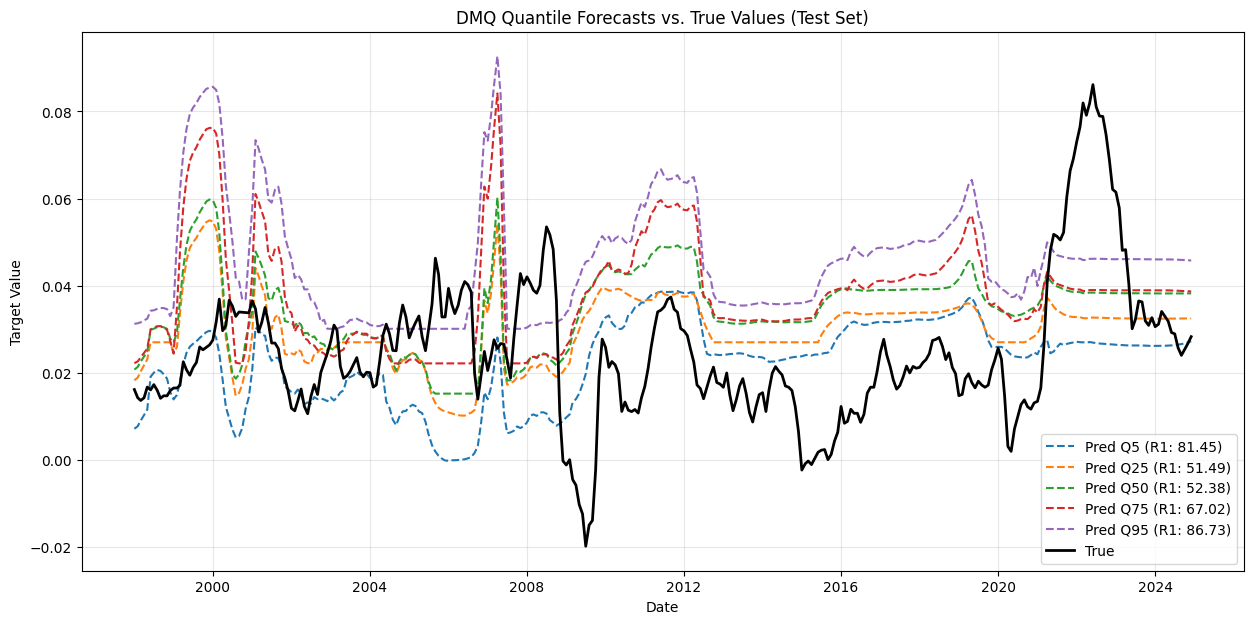

In [19]:
# Plot the results
plt.figure(figsize=(15, 7))
test_dates = pd.date_range(start=meta_data['test_start'], end='2024-12-01', freq='MS')

for i, q in enumerate(quantiles):
    plt.plot(test_dates, test_preds[:, i], label=f'Pred Q{int(q*100)} (R1: {r1_scores[i]:.2f})', linestyle='--')

plt.plot(test_dates, full_y_series.loc[meta_data['test_start']:'2024-12-01'].values, label='True', color='black', linewidth=2)

plt.title('DMQ Quantile Forecasts vs. True Values (Test Set)')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()